In [ ]:
# Install required libraries
!pip install -q openpyxl scikit-learn matplotlib seaborn joblib

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
uploaded = files.upload()

Saving expense_training_dataset_3_months_6000.xlsx to expense_training_dataset_3_months_6000.xlsx


In [ ]:
# Get uploaded filename
file_name = list(uploaded.keys())[0]

# Read Excel file
df = pd.read_excel(file_name)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (6000, 7)


,transaction_id,transaction_date,source,amount,payment_method,expense_mode,category
0,1702,2026-05-01,bus ticket to university,6507.49,Debit Card,Personal,Transport
1,1516,2026-05-01,KFC lunch for family,3529.49,Credit Card,Personal,Food
2,5567,2026-05-01,train ticket to university,12105.54,Mobile Payment,Personal,Transport
3,1507,2026-05-01,internet bill,1933.76,Credit Card,Personal,Bills
4,3614,2026-05-01,trip expenses,87387.63,Debit Card,Personal,Travel


In [ ]:
# Display column names
print("Columns:")
print(df.columns.tolist())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Display category distribution
print("\nCategory distribution:")
print(df["category"].value_counts())

Columns:
['transaction_id', 'transaction_date', 'source', 'amount', 'payment_method', 'expense_mode', 'category']

Missing values:
transaction_id      0
transaction_date    0
source              0
amount              0
payment_method      0
expense_mode        0
category            0
dtype: int64

Duplicate rows: 0

Category distribution:
category
Food             1200
Transport         825
Shopping          816
Bills             792
Entertainment     655
Education         580
Travel            570
Health            562
Name: count, dtype: int64


In [ ]:
# Keep only rows where source and category are available
df = df.dropna(subset=["source", "category"])

# Convert source to string
df["source"] = df["source"].astype(str).str.strip()

# Convert category to string
df["category"] = df["category"].astype(str).str.strip()

# Remove empty source values
df = df[df["source"] != ""]

# Remove duplicate source-category combinations
df = df.drop_duplicates(subset=["source", "category"])

print("Dataset after cleaning:", df.shape)

df.head()

Dataset after cleaning: (278, 7)


,transaction_id,transaction_date,source,amount,payment_method,expense_mode,category
0,1702,2026-05-01,bus ticket to university,6507.49,Debit Card,Personal,Transport
1,1516,2026-05-01,KFC lunch for family,3529.49,Credit Card,Personal,Food
2,5567,2026-05-01,train ticket to university,12105.54,Mobile Payment,Personal,Transport
3,1507,2026-05-01,internet bill,1933.76,Credit Card,Personal,Bills
4,3614,2026-05-01,trip expenses,87387.63,Debit Card,Personal,Travel


In [ ]:
df = df.dropna(subset=["source", "category"])

df["source"] = df["source"].astype(str).str.strip()
df["category"] = df["category"].astype(str).str.strip()

df = df[df["source"] != ""]

print("Dataset after cleaning:", df.shape)

Dataset after cleaning: (278, 7)


In [ ]:
# Input feature
X = df["source"]

# Target label
y = df["category"]

print("Input example:")
print(X.iloc[0])

print("\nTarget category:")
print(y.iloc[0])

Input example:
bus ticket to university

Target category:
Transport


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 222
Testing samples: 56


In [ ]:
logistic_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=1
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000
        )
    )
])

# Train model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model training completed!")

Logistic Regression model training completed!


In [ ]:
# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

# Calculate metrics
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted",
    zero_division=0
)
recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted",
    zero_division=0
)
f1_logistic = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted",
    zero_division=0
)

print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall   :", round(recall_logistic, 4))
print("F1 Score :", round(f1_logistic, 4))

Logistic Regression Results
--------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        zero_division=0
    )
)

               precision    recall  f1-score   support

        Bills       1.00      1.00      1.00         7
    Education       1.00      1.00      1.00         6
Entertainment       1.00      1.00      1.00         6
         Food       1.00      1.00      1.00        11
       Health       1.00      1.00      1.00         5
     Shopping       1.00      1.00      1.00         8
    Transport       1.00      1.00      1.00         8
       Travel       1.00      1.00      1.00         5

     accuracy                           1.00        56
    macro avg       1.00      1.00      1.00        56
 weighted avg       1.00      1.00      1.00        56



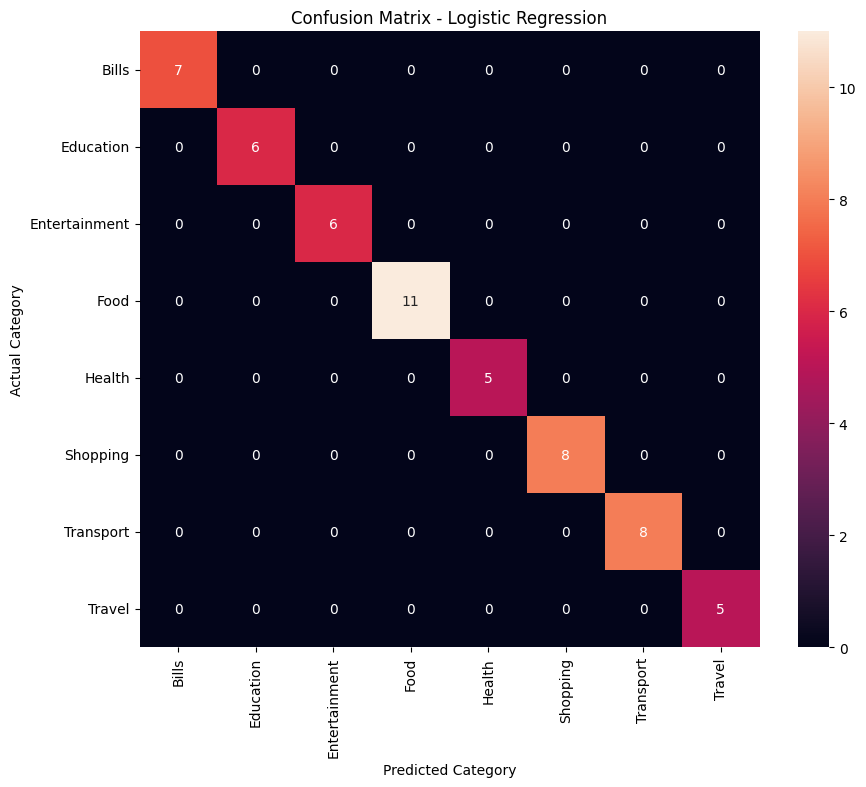

In [ ]:
# Get category labels
labels = sorted(y.unique())

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=labels
)

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [ ]:
new_expenses = [
    "KFC lunch with friends",
    "Uber ride to university",
    "Electricity payment for home",
    "Bought a new pair of shoes",
    "University programming textbook",
    "Bought medicine from pharmacy",
    "Netflix monthly payment",
    "Hotel booking for holiday"
]

predictions = logistic_model.predict(new_expenses)

for expense, prediction in zip(new_expenses, predictions):
    print(f"Expense: {expense}")
    print(f"Predicted Category: {prediction}")
    print("-" * 50)

Expense: KFC lunch with friends
Predicted Category: Food
--------------------------------------------------
Expense: Uber ride to university
Predicted Category: Transport
--------------------------------------------------
Expense: Electricity payment for home
Predicted Category: Bills
--------------------------------------------------
Expense: Bought a new pair of shoes
Predicted Category: Shopping
--------------------------------------------------
Expense: University programming textbook
Predicted Category: Education
--------------------------------------------------
Expense: Bought medicine from pharmacy
Predicted Category: Health
--------------------------------------------------
Expense: Netflix monthly payment
Predicted Category: Bills
--------------------------------------------------
Expense: Hotel booking for holiday
Predicted Category: Travel
--------------------------------------------------


In [ ]:
naive_bayes_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2)
        )
    ),
    (
        "classifier",
        MultinomialNB()
    )
])

# Train
naive_bayes_model.fit(X_train, y_train)

# Predict
y_pred_nb = naive_bayes_model.predict(X_test)

# Metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)
recall_nb = recall_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)
f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

print("Naive Bayes Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1 Score :", round(f1_nb, 4))

Naive Bayes Results
--------------------------------
Accuracy : 0.9821
Precision: 0.9836
Recall   : 0.9821
F1 Score : 0.9815


In [ ]:
svm_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2)
        )
    ),
    (
        "classifier",
        LinearSVC()
    )
])

# Train
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)
recall_svm = recall_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)
f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

print("Linear SVM Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_svm, 4))
print("Precision:", round(precision_svm, 4))
print("Recall   :", round(recall_svm, 4))
print("F1 Score :", round(f1_svm, 4))

Linear SVM Results
--------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_nb,
        accuracy_svm
    ],
    "Precision": [
        precision_logistic,
        precision_nb,
        precision_svm
    ],
    "Recall": [
        recall_logistic,
        recall_nb,
        recall_svm
    ],
    "F1 Score": [
        f1_logistic,
        f1_nb,
        f1_svm
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
1,Naive Bayes,0.982143,0.983631,0.982143,0.981539
2,Linear SVM,1.000000,1.000000,1.000000,1.000000


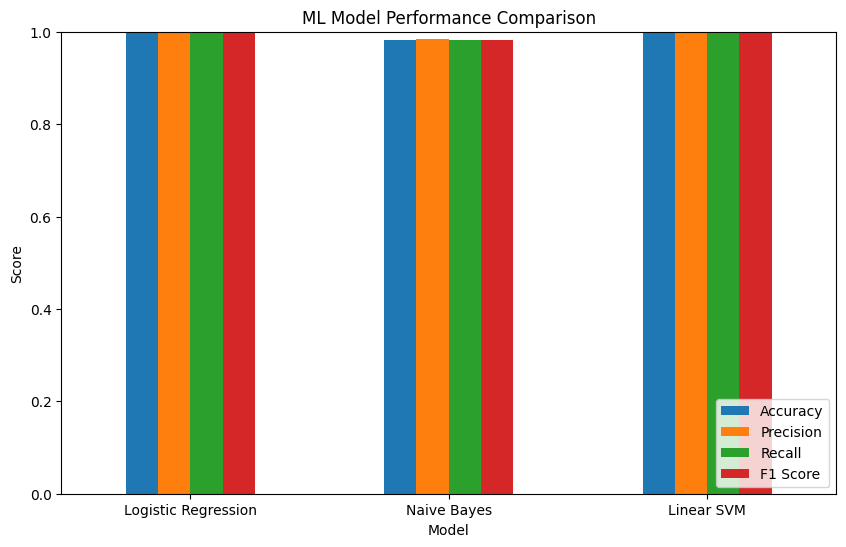

In [ ]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("ML Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

In [ ]:
model_scores = {
    "Logistic Regression": f1_logistic,
    "Naive Bayes": f1_nb,
    "Linear SVM": f1_svm
}

best_model_name = max(
    model_scores,
    key=model_scores.get
)

print("Best Model:", best_model_name)
print("Best F1 Score:", model_scores[best_model_name])

Best Model: Logistic Regression
Best F1 Score: 1.0


In [ ]:
models = {
    "Logistic Regression": logistic_model,
    "Naive Bayes": naive_bayes_model,
    "Linear SVM": svm_model
}

best_model = models[best_model_name]

joblib.dump(
    best_model,
    "expense_category_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


In [ ]:
loaded_model = joblib.load(
    "expense_category_model.pkl"
)

test_expenses = [
    "KFC lunch",
    "Uber ride",
    "Electricity bill",
    "New shoes",
    "University book",
    "Medicine from pharmacy",
    "Netflix subscription",
    "Hotel booking"
]

predictions = loaded_model.predict(test_expenses)

for expense, category in zip(test_expenses, predictions):
    print(
        f"{expense}  -->  {category}"
    )

KFC lunch  -->  Food
Uber ride  -->  Transport
Electricity bill  -->  Bills
New shoes  -->  Shopping
University book  -->  Education
Medicine from pharmacy  -->  Health
Netflix subscription  -->  Entertainment
Hotel booking  -->  Travel


In [ ]:
# Enter your own expense description
expense = input("Enter your expense description: ")

# Predict category
prediction = loaded_model.predict([expense])

# Display result
print("\nExpense:", expense)
print("Predicted Category:", prediction[0])

Enter your expense description: medical fees 4000

Expense: medical fees 4000
Predicted Category: Health


In [ ]:
models = {
    "Logistic Regression": logistic_model,
    "Naive Bayes": naive_bayes_model,
    "Linear SVM": svm_model
}

best_model = models[best_model_name]

joblib.dump(
    best_model,
    "expense_category_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


In [ ]:
results = {
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2,
    "MAPE": mape
}

print("Regression Model Performance")
print("-----------------------------")

for metric, value in results.items():
    print(f"{metric}: {value}")

NameError: name 'mae' is not defined